In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    f1_score, precision_score,
    recall_score,roc_curve, roc_auc_score, accuracy_score
)

In [2]:
df = pd.read_csv('/media/prince/5A4E832F4E83034D/lead-conversion-predictor/Data/finalized_feas.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9239 entries, 0 to 9238
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Lead Origin                      9239 non-null   object 
 1   Do Not Email                     9239 non-null   object 
 2   Converted                        9239 non-null   int64  
 3   Total Time Spent on Website      9239 non-null   int64  
 4   Last Activity                    9239 non-null   object 
 5   Specialization                   9239 non-null   object 
 6   What is your current occupation  9239 non-null   object 
 7   Asymmetrique Activity Score      5021 non-null   float64
 8   Asymmetrique Profile Score       5021 non-null   float64
 9   occupation_known                 9239 non-null   bool   
dtypes: bool(1), float64(2), int64(2), object(5)
memory usage: 658.8+ KB


In [3]:
label = df['Converted']
predictors = df.drop(columns=['Converted']) 
x_train, x_test, y_train, y_test = train_test_split(
    predictors,
    label,
    test_size=0.2,
    random_state=42,
    stratify=label
)

In [4]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Converted
0    0.614666
1    0.385334
Name: proportion, dtype: float64
Converted
0    0.614719
1    0.385281
Name: proportion, dtype: float64


In [5]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7391 entries, 9045 to 3413
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Lead Origin                      7391 non-null   object 
 1   Do Not Email                     7391 non-null   object 
 2   Total Time Spent on Website      7391 non-null   int64  
 3   Last Activity                    7391 non-null   object 
 4   Specialization                   7391 non-null   object 
 5   What is your current occupation  7391 non-null   object 
 6   Asymmetrique Activity Score      4039 non-null   float64
 7   Asymmetrique Profile Score       4039 non-null   float64
 8   occupation_known                 7391 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(5)
memory usage: 526.9+ KB


In [6]:
num_cols = ['Total Time Spent on Website']
bool_cols = ['occupation_known']
cat_cols = [col for col in predictors.columns if col not in num_cols and bool_cols]

In [7]:
def log_transform(x):
    return np.log1p(x)

def to_str_func(x):
    return x.astype(str)

num_pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p, validate=False)),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('to_str', FunctionTransformer(to_str_func)),
    ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols),
])

final_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

final_pipe.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('log',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Total Time Spent on '
                                                   'Website']),
                                                 ('cat',
                                                  Pipeline(steps=[('to_str',
                                                                   FunctionTransformer(func=<function to_str_func at 0x7e0b699d3100>)),
                                                                  ('impute',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Lead Origin',
                                                   'Do Not Email',
                                                   'Last Activity',
                                                   'Specialization',
                                                   'What is your current '
                                                   'occupation',
                                                   'Asymmetrique Activity '
                                                   'Score',
                                                   'Asymmetrique Profile Score',
                                                   'occupation_known'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [ ]:
model = final_pipe
y_train_pred = cross_val_predict( model, x_train, y_train , cv= 5 )

In [9]:
print(precision_score(y_train, y_train_pred , pos_label=1 ) * 100)
print(recall_score(y_train, y_train_pred, pos_label= 1) * 100)

77.72613514479801
76.33426966292134


In [10]:
f1_score(y_train, y_train_pred) * 100

77.02391496899912

In [11]:
acc = accuracy_score(y_train, y_train_pred)
print(acc) 

0.8245163036125017


In [ ]:
y_scores = cross_val_predict( model, x_train, y_train , cv= 5 , method='predict_proba')[:, 1]

In [ ]:
import joblib
# joblib.dump(model, '/media/prince/5A4E832F4E83034D/lead-conversion-predictor/Models/rf_model.pkl')

['/media/prince/5A4E832F4E83034D/lead-conversion-predictor/Models/rf_model.pkl']

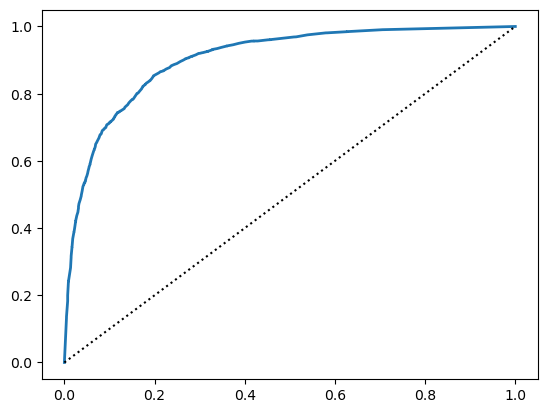

In [14]:
fpr, tpr , thresholds = roc_curve(y_train, y_scores)
plt.plot(fpr, tpr, linewidth=2 , label= "Roc curve")
plt.plot([0,1],[0,1],'k:', label="Random classifier's ROC curve")
plt.show()

In [15]:
roc_auc_score(y_train, y_scores)

np.float64(0.9034959250186112)

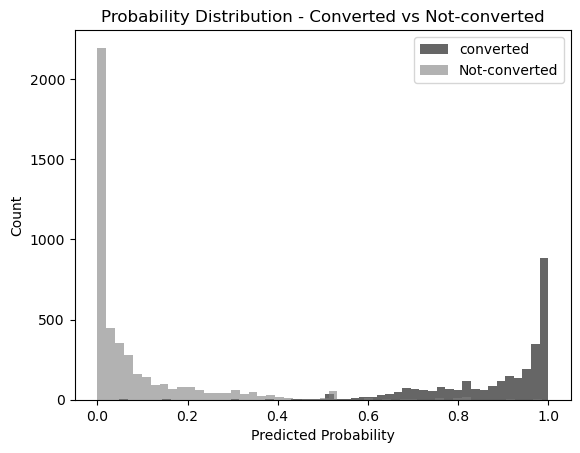

In [ ]:
coversion_probs = model.predict_proba(x_train)[y_train == 1, 1]
non_coversion_probs = model.predict_proba(x_train)[y_train == 0, 1]

import matplotlib.pyplot as plt
plt.hist(coversion_probs, bins=50, alpha=0.6, label='converted', color='black')
plt.hist(non_coversion_probs, bins=50, alpha=0.6, label='Not-converted', color='grey')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Probability Distribution - Converted vs Not-converted')
plt.legend()
# plt.ylim(0, 5000)
plt.show()

In [17]:
print(f"conversion Mean:      {coversion_probs.mean():.4f}")
print(f"Non-conversion Mean:  {non_coversion_probs.mean():.4f}")
print(f"Gap:             {(coversion_probs.mean() - non_coversion_probs.mean()):.4f}")
print(f"conversion Max:       {coversion_probs.max():.4f}")
print(f"Non conversion max: {non_coversion_probs.max():.4f}")
print(f"conversion Std:         {coversion_probs.std():.4f}")
print(f"Non-conversion Std:     {non_coversion_probs.std():.4f}")

conversion Mean:      0.8866
Non-conversion Mean:  0.0793
Gap:             0.8073
conversion Max:       1.0000
Non conversion max: 0.9862
conversion Std:         0.1359
Non-conversion Std:     0.1382
